<a href="https://colab.research.google.com/github/AgrisData/DATA_CLEANING_FEATURE_ENGINEERING_AGRICOLA/blob/main/DATA_CLEANING_%26_FEATURE_ENGINEERING_AGR%C3%8DCOLA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **FLUJO DE PREPARACIÓN Y LIMPIEZA DE DATOS AGRÍCOLAS PARA MODELOS DE APRENDIZAJE AUTOMÁTICO**

 En este notebook les comparto un pipeline robusto de data cleaning y feature engineering de variables abióticas que favorecen la posible incidencia del Fusarium R4T en el cultivo de banano (*Musa × paradisiaca L.*) 🍌 en cuatro provincias del Ecuador.

In [ ]:
#Principales librerias de trabajo
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# **Importamos el dataset**

In [ ]:
#Importamos el dataset de nuestra finca bananera
datos = pd.read_csv('dataset_fusarium.csv')

**Nota Importante:** Este dataset contiene variables artificiales generadas al azar (**np.random.normal()**), respetando las unidades y métricas pertinentes que cumplan con su propósito para este notebook que es netamente académico-práctico.

#**EDA (Análisis Explotatorio de Datos)**

In [ ]:
#Visualizamos los 5 primeros registros del dataset
datos.head()

,zona_monitoreo,ph_suelo,conductividad_electrica,textura_suelo,bioseguridad_nivel,temp_suelo_c,presencia_sintomas
0,Los Rios,6.90 pH,0.48069794686330714,FRANCO,Baja,26.028464,No
1,El Oro,4.41 pH,2.0770674162427962,Arenoso,Alta,21.151558,Si
2,Los Ríos,7.16 pH,0.7517129137869816,NaN,Alta,26.669657,Si
3,EL ORO,NaN,0.34659580588581607,Arcilloso,Media,28.801547,Si
4,Los Rios,7.08 pH,1.9792399295601588,Arenoso,Media,23.134774,Si


Una vista previa de los registros del dataset permite identificar posibles correcciones de escritura o formatos para evitar errores de redundancia al modelo.

In [ ]:
#Observamos el tipo de dato y valores nulos de las variables con la función  .info()
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   zona_monitoreo           950 non-null    object 
 1   ph_suelo                 763 non-null    object 
 2   conductividad_electrica  950 non-null    object 
 3   textura_suelo            786 non-null    object 
 4   bioseguridad_nivel       950 non-null    object 
 5   temp_suelo_c             950 non-null    float64
 6   presencia_sintomas       950 non-null    object 
dtypes: float64(1), object(6)
memory usage: 54.8+ KB


**Observación:** Se evidencia registros de tipo númerico con Dtype (tipo de formato) **Object** . Por ello se procede a su corrección previo al diseño del modelo de aprendizaje automático.

In [ ]:
#Eliminamos los posibles duplicados en el dataset
print(f"El número de registros en el dataset es de {datos.shape[0]} previo a la eliminación de datos duplicados")
datos.drop_duplicates(inplace=True)
print(f"El número de registros en el dataset es de {datos.shape[0]} posterior a la eliminación de datos duplicados")

El número de registros en el dataset es de 1000 previo a la eliminación de datos duplicados
El número de registros en el dataset es de 1000 posterior a la eliminación de datos duplicados


In [ ]:
#Identificamos y enlistamos las columnas numéricas con formato y datos erróneos
print(datos.columns)
col_sucias = ['ph_suelo','conductividad_electrica']

Index(['zona_monitoreo', 'ph_suelo', 'conductividad_electrica',
       'textura_suelo', 'bioseguridad_nivel', 'temp_suelo_c',
       'presencia_sintomas'],
      dtype='object')


In [ ]:
# Usamos la función apply() y empleamos un lambda para corregir de forma inmediata los datos numéricos erróneos
datos[col_sucias] = datos[col_sucias].apply(lambda x: pd.to_numeric(
    x.astype(str).str.replace(",",".").str.extract(r'(\d+\.?\d*)')[0], errors='coerce'))

In [ ]:
# Confirmamos las correciones del formato (Dtype) de los datos numéricos.
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   zona_monitoreo           950 non-null    object 
 1   ph_suelo                 763 non-null    float64
 2   conductividad_electrica  815 non-null    float64
 3   textura_suelo            786 non-null    object 
 4   bioseguridad_nivel       950 non-null    object 
 5   temp_suelo_c             950 non-null    float64
 6   presencia_sintomas       950 non-null    object 
dtypes: float64(3), object(4)
memory usage: 54.8+ KB


In [ ]:
# Visualizamos las correcciones hechas en el dataset
datos.head()

,zona_monitoreo,ph_suelo,conductividad_electrica,textura_suelo,bioseguridad_nivel,temp_suelo_c,presencia_sintomas
0,Los Rios,6.90,0.480698,FRANCO,Baja,26.028464,No
1,El Oro,4.41,2.077067,Arenoso,Alta,21.151558,Si
2,Los Ríos,7.16,0.751713,NaN,Alta,26.669657,Si
3,EL ORO,NaN,0.346596,Arcilloso,Media,28.801547,Si
4,Los Rios,7.08,1.979240,Arenoso,Media,23.134774,Si


# **Data Engineering variables categóricas**

In [ ]:
#Del dataset dividiremos los registros según el tipo de variable sea numéricos o categóricos
#Variables Categóricas
categoricos = datos.select_dtypes(include=['object']).columns.tolist()
categoricos

['zona_monitoreo', 'textura_suelo', 'bioseguridad_nivel', 'presencia_sintomas']

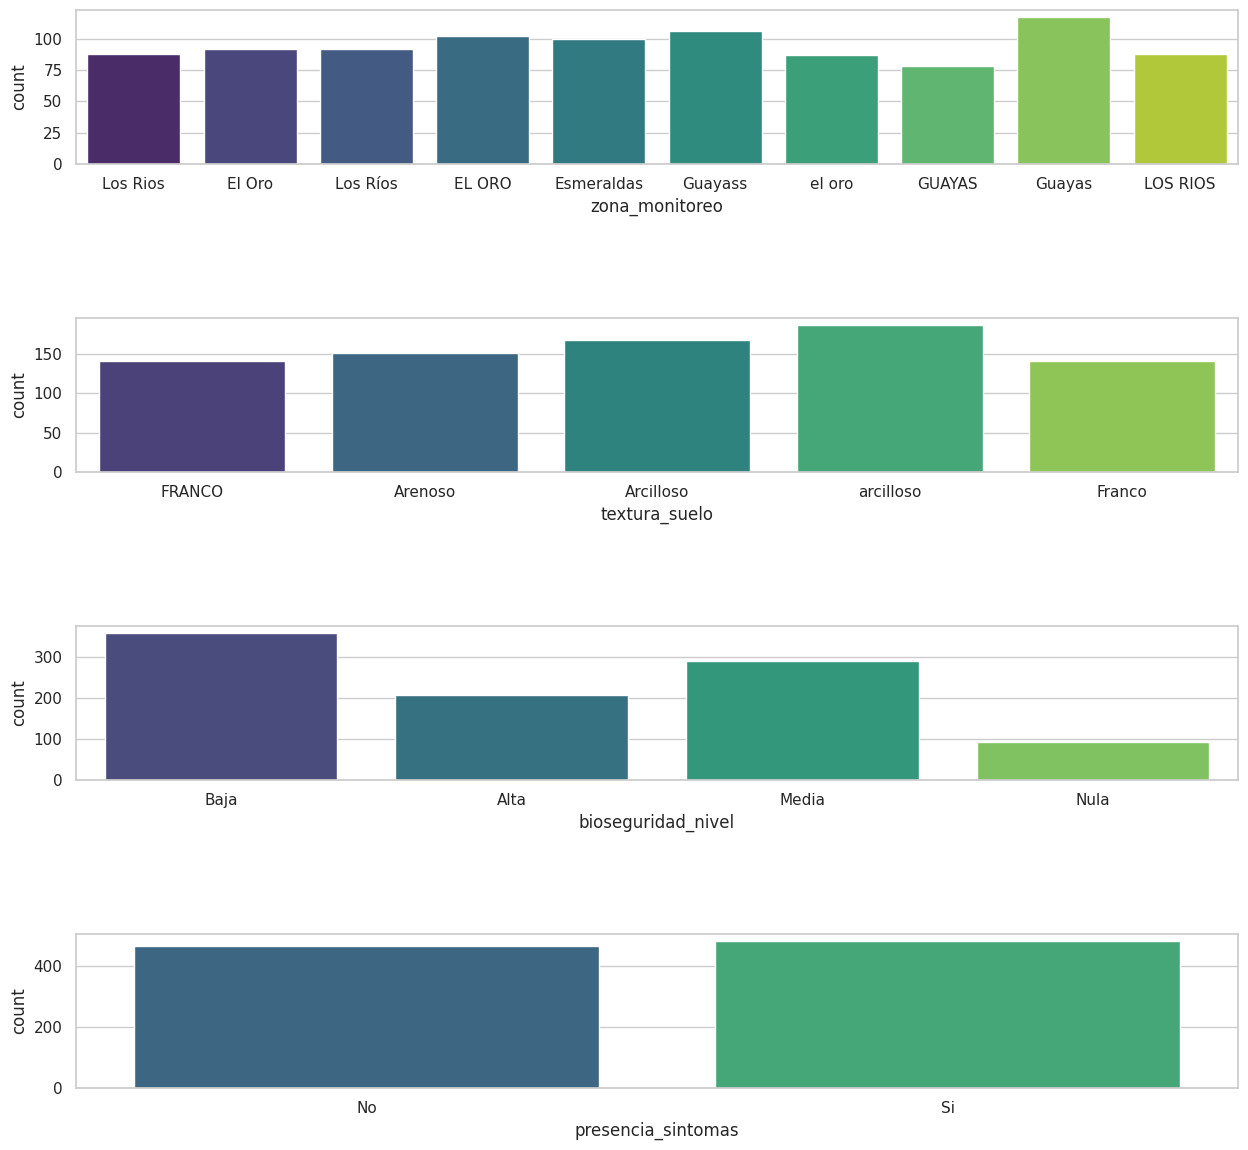

In [ ]:
#Procedemos a ver la frecuencia de los datos categoricos en las distintas columnas mediante countplots.
sns.set_theme(style='whitegrid')
fig, ax = plt.subplots(nrows=4, ncols=1, figsize=(15,14))
plt.subplots_adjust(hspace=1)
for i, col in enumerate(categoricos):
  sns.countplot(data=datos,x=col,palette='viridis',hue=col, ax=ax[i], legend=False)


**Observación:**
Se observan datos repetidos con variaciones en su escritura en las columnas: *zona_monitoreo*, *textura_suelo*.
Sino se corrige el modelo interpretaria cada una como una categoría distinta y, en consecuencia, aprende patrones incorrectos.

In [ ]:
#Importamos unicodedata una librería útil para trabajar de manera global con el formato de caracteres alfanuméricos
import unicodedata

In [ ]:
#Este código abreviado con apply() + lambda x, eliminamos las variaciones de un dato categórico en un estándar de minúsculas sin espacios para el modelo.
datos[categoricos] = datos[categoricos].apply(lambda x: x.str.normalize('NFKD').str.encode('ascii', errors='ignore')\
                                       .str.decode('utf-8').str.lower().str.strip().str.replace(" ","_"))

In [ ]:
# Recorremos los valores de las columnas categóricas con un bucle para identificar otro tipo de errores o variaciones en sus registros.
for col in datos[categoricos].columns:
  print("========"*20)
  print(datos[col].value_counts())

zona_monitoreo
el_oro        281
los_rios      268
guayas        195
guayass       106
esmeraldas    100
Name: count, dtype: int64
textura_suelo
arcilloso    353
franco       282
arenoso      151
Name: count, dtype: int64
bioseguridad_nivel
baja     359
media    291
alta     207
nula      93
Name: count, dtype: int64
presencia_sintomas
si    482
no    468
Name: count, dtype: int64


In [ ]:
#Unimos datos corrigiendo los errores tipográficos de los registros.
#zona_monitoreo: guayass --> guayas
datos.loc[datos['zona_monitoreo'] == 'guayass', 'zona_monitoreo'] = 'guayas'

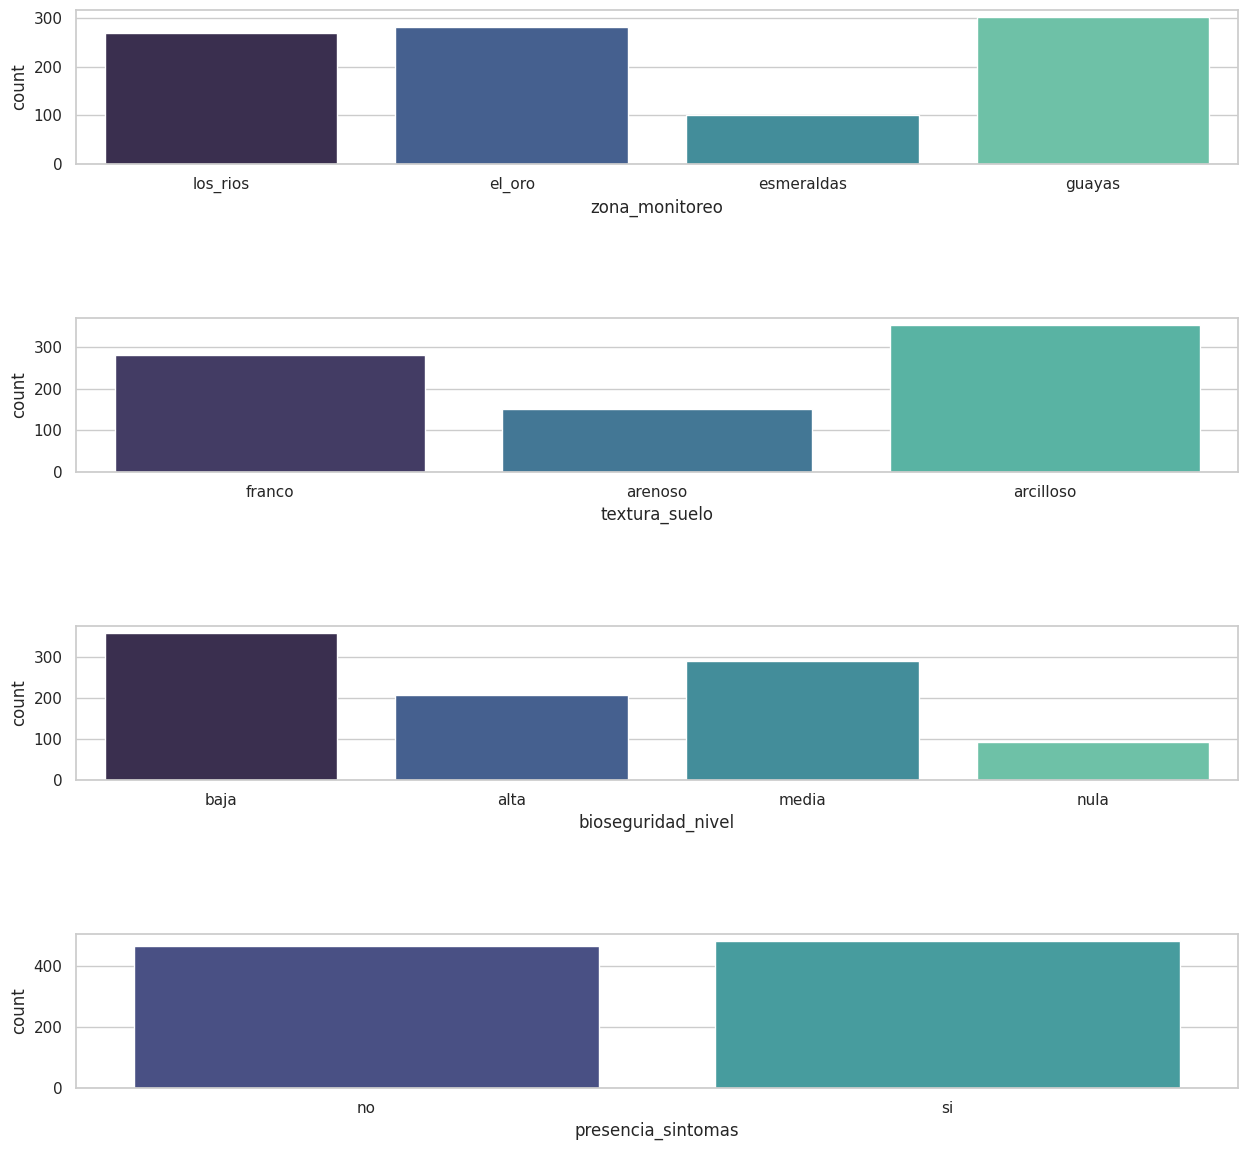

In [ ]:
#Verificamos como se reduce el número de barras con respecto a la frecuencia de un registro mediante otro countplot.
sns.set_theme(style='whitegrid')
fig, ax = plt.subplots(nrows=4, ncols=1, figsize=(15,14))
plt.subplots_adjust(hspace=1)
for i, col in enumerate(categoricos):
  sns.countplot(data=datos, x=col, palette='mako', hue=col, ax=ax[i], legend=False)


In [ ]:
#Identificamos los registros nulos en las variables categóricas
datos[categoricos].isna().sum()

,0
zona_monitoreo,50
textura_suelo,214
bioseguridad_nivel,50
presencia_sintomas,50


In [ ]:
# Imprimimos la proporción de los registos categóricos
for col in datos[categoricos].columns:
  print("======="*20)
  print(datos[col].value_counts(normalize=True).round(3)*100) # Usamos normalize=True para conocer su proporción equivalente previo a la imputación.

zona_monitoreo
guayas        31.7
el_oro        29.6
los_rios      28.2
esmeraldas    10.5
Name: proportion, dtype: float64
textura_suelo
arcilloso    44.9
franco       35.9
arenoso      19.2
Name: proportion, dtype: float64
bioseguridad_nivel
baja     37.8
media    30.6
alta     21.8
nula      9.8
Name: proportion, dtype: float64
presencia_sintomas
si    50.7
no    49.3
Name: proportion, dtype: float64


In [ ]:
datos = datos.dropna(subset=['presencia_sintomas']) #Obligatoriamente debemos eliminar los valores nulos de nuestra variable target.
for col in categoricos:
  probabilidad = datos[col].value_counts(normalize=True)
  mask_nulos = datos[col].isna()
  if mask_nulos.sum()>0:
    datos.loc[mask_nulos,col]  = np.random.choice(probabilidad.index,p=probabilidad.values,size=mask_nulos.sum())

In [ ]:
#Se corrobora el éxito de la imputación
datos[categoricos].isna().sum()

,0
zona_monitoreo,0
textura_suelo,0
bioseguridad_nivel,0
presencia_sintomas,0


In [ ]:
for col in datos[categoricos].columns:
  print("======="*20)
  print(datos[col].value_counts(normalize=True).round(3)*100)# Usamos normalize=True para conocer su proporción equivalente posterior a la imputación.

zona_monitoreo
guayas        31.4
el_oro        29.6
los_rios      28.5
esmeraldas    10.5
Name: proportion, dtype: float64
textura_suelo
arcilloso    46.1
franco       35.1
arenoso      18.8
Name: proportion, dtype: float64
bioseguridad_nivel
baja     37.4
media    30.9
alta     22.1
nula      9.6
Name: proportion, dtype: float64
presencia_sintomas
si    50.7
no    49.3
Name: proportion, dtype: float64


**Nota:** La imputación proporcional se diferencia de la simple, debido a que no considera la moda como medida de imputación, sino la distribución proporcional de los datos, respetando la equidad e integridad del dataset, consigo se logra reflejar la realidad de la situación para el entrenamiento del modelo.

In [ ]:
#Conteo de registros por variable(columna) categórica
for col in categoricos:
  print(f"El número de elementos de la variable {col} es de: {datos[col].nunique()}")

El número de elementos de la variable zona_monitoreo es de: 4
El número de elementos de la variable textura_suelo es de: 3
El número de elementos de la variable bioseguridad_nivel es de: 4
El número de elementos de la variable presencia_sintomas es de: 2


# **Data Engineering variables numéricas**

In [ ]:
#Variables numéricas
numericos = datos.select_dtypes(exclude=['object']).columns.tolist()
numericos

['ph_suelo', 'conductividad_electrica', 'temp_suelo_c']

In [ ]:
#El data engineer de las variables numéricas siempre parte con el análisis del resumen estadístico.
datos.describe().round(3) #la función describe() nos permite visualizar los parámetros estadísticas más importantes.

,ph_suelo,conductividad_electrica,temp_suelo_c
count,730.000,773.000,901.000
mean,5.955,1.295,50.878
std,1.167,0.692,107.802
min,4.000,0.113,20.022
25%,4.900,0.691,22.872
50%,5.980,1.298,25.304
75%,6.967,1.920,27.836
max,8.000,2.499,500.000


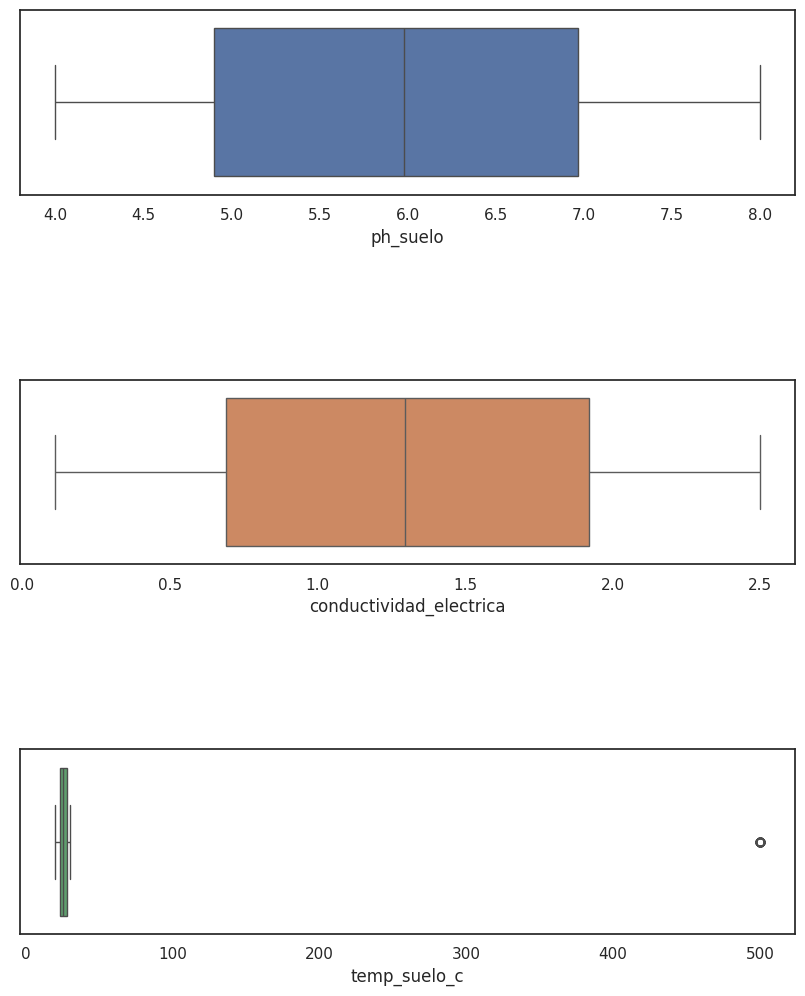

In [ ]:
#Identificamos outliers con boxplots por variable (columna)
sns.set_theme(style='white')
fig,ax = plt.subplots(nrows=3, ncols=1, figsize=(10,12))
plt.subplots_adjust(hspace=1)
for i,col in enumerate(numericos):
  colores = sns.color_palette('deep', n_colors=len(numericos))
  sns.boxplot(data=datos, x=col, color=colores[i], ax=ax[i])

In [ ]:
#Una manera más técnica de manejar valores atípicos es convertirlos a NULOS para luego imputar y no perder información.
#Usamos el método de Tukey
temp = datos['temp_suelo_c']
Q1 = temp.quantile(0.25)
Q3 = temp.quantile(0.75)
IQR = Q3 - Q1
LIMIT_INF = Q1 - IQR*1.5
LIMIT_SUP = Q3 + IQR*1.5

In [ ]:
# Enmascaramos con la función  mask() en base a los límites propuestos por el método de Tukey
datos['temp_suelo_c'] = datos['temp_suelo_c'].mask((temp<LIMIT_INF) | (temp>LIMIT_SUP))

**Nota:** Una regla de oro al momento de manejar outliers es la no eliminación de los mismos, debido a la perdida de información valiosa que le podría resultar util al modelo, ante esto se puede optar por convertirlos a valores no numéricos (NaN) o vacíos (Null), para posteriormente usar técnicas de imputación.

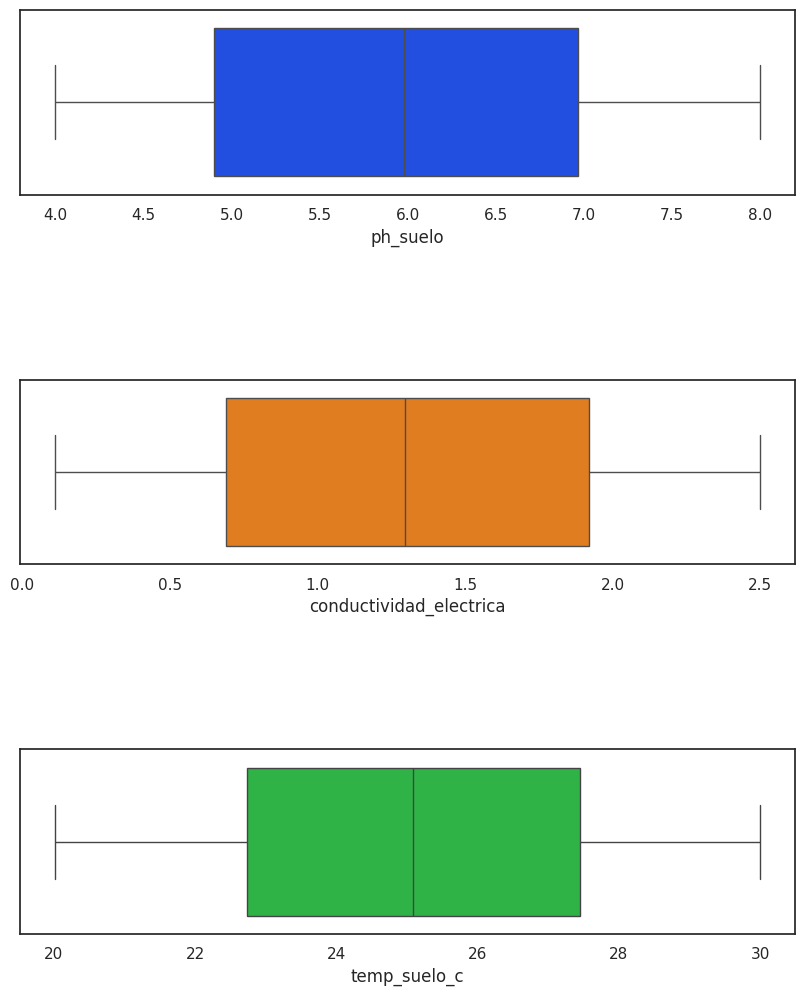

In [ ]:
#Nuevamente graficamos y evidenciamos que enmascaramos los outliers con valores nulos.
sns.set_theme(style='white')
fig,ax = plt.subplots(nrows=3,ncols=1, figsize=(10,12))
plt.subplots_adjust(hspace=1)
colores = sns.color_palette('bright', n_colors=(len(numericos)))
for i, col in enumerate(numericos):
  sns.boxplot(data=datos,x=col,color=colores[i], ax=ax[i])

In [ ]:
#Correlacionamos los datos
correlacion = datos[numericos].corr()
correlacion

,ph_suelo,conductividad_electrica,temp_suelo_c
ph_suelo,1.000000,0.004787,0.030044
conductividad_electrica,0.004787,1.000000,-0.053939
temp_suelo_c,0.030044,-0.053939,1.000000


**Nota:** Es mediante el mapa de calor que visualizamos como interactuan los factores del campo. La correlación mide qué tan fuerte es la relación lineal entre dos variables (por ejemplo, si al subir el Nitrógeno siempre sube el Rendimiento).

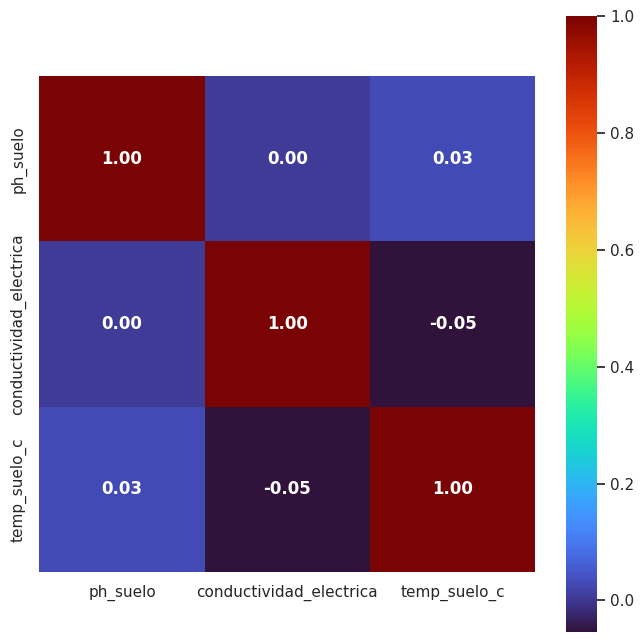

In [ ]:
with sns.axes_style('white'):
  fig,ax = plt.subplots(figsize=(8,8))
  paleta = sns.color_palette('turbo', as_cmap=True)
  sns.heatmap(correlacion, annot=True, fmt='.2f', annot_kws={'size':12,'weight':'bold'}, cmap=paleta, square=True)


**Observación:** Se evidencia baja correlación entre las variables numéricas, consigo se destaca ventaja, debido a que cada una aporta algo nuevo y único al modelo. Se podría decir que es un modelo estable con notable ausencia de multicolinealidad.

**Importante:** Cuando se observa más de una correlación significativa, se opta por eliminar una de las variables (columna), esto es para reducir el nivel de ruido en la información de entrada (X), en respuesta el modelo no se confundira al momento predecir que variable fue importante para el resultado obtenido.

In [ ]:
#Verificamos el total de datos nulos por variable numérica
datos[numericos].isna().sum()

,0
ph_suelo,220
conductividad_electrica,177
temp_suelo_c,98


In [ ]:
#Importamos las librerias para poder imputar mediante MICE
from sklearn.experimental import enable_iterative_imputer #habilitamos el imputador iterativo
from sklearn.impute import IterativeImputer

In [ ]:
imputador = IterativeImputer(max_iter=10, random_state=0) #Validamos el imputador
datos[numericos] = imputador.fit_transform(datos[numericos])

In [ ]:
#Confirmamos que la imputación MICE se realizo con éxito
datos[numericos].isna().sum()

,0
ph_suelo,0
conductividad_electrica,0
temp_suelo_c,0


**Nota:** La imputación **MICE** (Imputación multivariante por ecuaciones encadenadas), es la más robusta al momento de acercarnos a valores reales de datos faltantes en nuestro dataset.

In [ ]:
#Contabilizamos el total de registros de las variables numéricas
for col in datos[numericos]:
  print(f"El número de elementos de la variable {col} es de: {datos[col].nunique()}")

El número de elementos de la variable ph_suelo es de: 559
El número de elementos de la variable conductividad_electrica es de: 947
El número de elementos de la variable temp_suelo_c es de: 947


In [ ]:
#Reseteamos el indice de los registros para evitar problemas de sobreescritura
datos.reset_index(drop=True, inplace=True)
datos.info(verbose=False) #Especificamos no verboso el contenido

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 950 entries, 0 to 949
Columns: 7 entries, zona_monitoreo to presencia_sintomas
dtypes: float64(3), object(4)
memory usage: 52.1+ KB


**Nota:** Se aplicó un reset_index tras la limpieza de outliers y tratamiento de nulos para garantizar la integridad referencial y la alineación de tensores antes de la fase de entrenamiento.

#**Procesamiento y separación de variables X , y**


In [ ]:
#Liberías para convertir variables categóricas en numéricas
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer

In [ ]:
datos.columns

Index(['zona_monitoreo', 'ph_suelo', 'conductividad_electrica',
       'textura_suelo', 'bioseguridad_nivel', 'temp_suelo_c',
       'presencia_sintomas'],
      dtype='object')

In [ ]:
# variables X
X = datos.drop('presencia_sintomas', axis=1)

In [ ]:
# variable target -> y
y = datos['presencia_sintomas']

In [ ]:
#Eliminamos la variable TARGET del conjunto CATEGORICOS
categoricos.remove('presencia_sintomas')

In [ ]:
#Validamos la función de ColumnTransformer y OneHotEncoder
procesamiento = ColumnTransformer(
    transformers=[
        ('cat', #prefijo de nombre columna categórica.
         OneHotEncoder(handle_unknown='ignore',sparse_output=False), #Que ignore datos desconocidos y los datos de salida no sean dispersos.
         categoricos)], #La lista de las variables categóricas sin la target(y)
    remainder='passthrough') #Permita el flujo de las variables restantes (numéricas)

In [ ]:
#Imprimimos la configuración de procesamiento de las variables categóricas
procesamiento

ColumnTransformer(remainder='passthrough',
                  transformers=[('cat',
                                 OneHotEncoder(handle_unknown='ignore',
                                               sparse_output=False),
                                 ['zona_monitoreo', 'textura_suelo',
                                  'bioseguridad_nivel'])])

**Nota:** **'cat'** es un prefijo asignado al nombre de las variables categóricas convertidas a datos binarios y **remainder='passthrough'**, permite el flujo normal de las variables númericas. Esto se evidencia más abajo en el DataFrame final de las variables X.

In [ ]:
#Codificamos las variables categóricas con la configuración preestablecida.
X_procesada = procesamiento.fit_transform(X)

In [ ]:
#Extraemos los nombres de las columnas procesadas.
nombres_col = procesamiento.get_feature_names_out()

In [ ]:
#Sobreescribimos nuestras variables independientes (X) como DataFrame con el nombre de las columnas extraidas.
X = pd.DataFrame(X_procesada, columns=nombres_col)

In [ ]:
#Visualizamos la codificación binaria de las variables categóricas
X

,cat__zona_monitoreo_el_oro,cat__zona_monitoreo_esmeraldas,cat__zona_monitoreo_guayas,cat__zona_monitoreo_los_rios,cat__textura_suelo_arcilloso,cat__textura_suelo_arenoso,cat__textura_suelo_franco,cat__bioseguridad_nivel_alta,cat__bioseguridad_nivel_baja,cat__bioseguridad_nivel_media,cat__bioseguridad_nivel_nula,remainder__ph_suelo,remainder__conductividad_electrica,remainder__temp_suelo_c
0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,6.900000,0.480698,26.028464
1,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,4.410000,2.077067,21.151558
2,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,7.160000,0.751713,26.669657
3,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,5.960828,0.346596,28.801547
4,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,7.080000,1.979240,23.134774
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
945,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,7.470000,1.749509,25.067187
946,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,6.550000,1.613722,23.967276
947,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,5.210000,1.294873,25.032051
948,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,5.951280,1.855749,22.408781


In [ ]:
#Procesamos nuestra variable target a datos binarios
procesamiento_y = LabelEncoder()
y_procesada = procesamiento_y.fit_transform(y)

In [ ]:
#Convertimos a DataFrame
y = pd.DataFrame(y_procesada, columns=['presencia_sintomas'])

In [ ]:
#Visualizamos la codificación binaria de la variable target
y

,presencia_sintomas
0,0
1,1
2,1
3,1
4,1
...,...
945,1
946,0
947,1
948,0


In [ ]:
#Usamos la librería train_test_split para entrenar y probar los datos
from sklearn.model_selection import train_test_split

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2, random_state=42)

Hasta aquí tendriamos todo el flujo de trabajo completo con un dataset adecuado para su entrenamiento y prueba con el modelo de clasificación de su interés.

**Autor:** *Ing. Agr. Washington Vera Beltrán*

Para más información contactar al **+593 978919608**